# ADS-509 Assignment 2.1
## Text Cleaning and Exploration


In this assignment, you will use the HackerNews dataset created in the Module 1 assignment to:
- Clean, normalize, and tokenize text
- Explore and analyze text
- Vectorize text
- Perform basic sentiment analysis
  
If you are not confident in the quality of your own dataset from Module 1, there is a clean dataset available for your use in the assignment repository on GitHub.

## Imports and Downloads

We will be using some datasets from the NLTK library, so we need to make sure that these are downloaded correctly before trying to use them. Then we will import the rest of the libraries that we will use.

In [7]:
# Download NLTK resources
import nltk
for res in ['punkt','punkt_tab','stopwords','vader_lexicon']:
    nltk.download(res)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sushmakafle/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sushmakafle/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sushmakafle/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/sushmakafle/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
import os, re, math, string, random, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import sparse

# set some parameters for our visualizations
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 120


## Load Data

Next we will load our dataset from Module 1 and double check that it is formatted correctly.

If you are uncertain about your own dataset, or if you don't pass the check below, feel free to use the dataset provided on Canvas.

In [11]:
DATA_PATH = '/Users/sushmakafle/Documents/Master/ADS_509/Module1/ADS-509-module1/data/module1/hn_comments_with_storymeta.csv'  # TODO: Update the file path as needed

assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Update the path for your environment."

In [13]:
df = pd.read_csv(DATA_PATH)
print('Rows:', len(df))
expected_cols = {'comment_text','story_id','title','score','descendants','story_time'}
missing = expected_cols - set(df.columns)
if missing:
    print('Warning: missing expected columns:', missing)
df.head()

Rows: 5649


,story_id,comment_id,user,time_text,comment_text,id,title,by,story_time,url,score,descendants
0,49668386,49669031,lubujackson,13 minutes ago,As much as I am sad that Google died like 15 y...,49668386,Google no longer provides direct URLs in searc...,1e1a,2026-09-12 03:14:20,https://www.autom.dev/blog/google-search-goto-...,176,92
1,49668386,49669059,bitpush,9 minutes ago,> There are still illegal streaming sports and...,49668386,Google no longer provides direct URLs in searc...,1e1a,2026-09-12 03:14:20,https://www.autom.dev/blog/google-search-goto-...,176,92
2,49668386,49669084,leobg,5 minutes ago,The pain being made is: If you use a search en...,49668386,Google no longer provides direct URLs in searc...,1e1a,2026-09-12 03:14:20,https://www.autom.dev/blog/google-search-goto-...,176,92
3,49668386,49669080,sofixa,6 minutes ago,"> Yandex. It reminds me of old Google, returni...",49668386,Google no longer provides direct URLs in searc...,1e1a,2026-09-12 03:14:20,https://www.autom.dev/blog/google-search-goto-...,176,92
4,49668386,49669066,userbinator,8 minutes ago,I was suspicious when they started obfuscating...,49668386,Google no longer provides direct URLs in searc...,1e1a,2026-09-12 03:14:20,https://www.autom.dev/blog/google-search-goto-...,176,92


## Text Cleaning and Normalization

Now we will clean up the text in the `comment_text` column of the dataset. There are many different cleaning steps that are common for text, depending on your data source and use case. For the purpose of this assignment, we will keep it fairly simple.

**TODO:**

Perform the following steps on the `comment_text` column:
- Convert to lower case
- Remove any URLs
- Strip any extra whitespace

In [15]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')
def normalize_text(s):
    if not isinstance(s, str):
        return ''
    # TODO: convert text to lowercase, remove URLs from the text using the regex from above, and remove extra white space
    
    s = s.lower() # convert text to lowercase
    s = URL_RE.sub('', s)  # remove URLs
    s = ' '.join(s.split())   # remove extra white space
    
    return s

df['text_norm'] = df['comment_text'].apply(normalize_text)
df[['comment_text','text_norm']].head(3)

,comment_text,text_norm
0,As much as I am sad that Google died like 15 y...,as much as i am sad that google died like 15 y...
1,> There are still illegal streaming sports and...,> there are still illegal streaming sports and...
2,The pain being made is: If you use a search en...,the pain being made is: if you use a search en...


## Tokenization

In natural language processing, tokenization is the process of splitting raw text into individual units for analysis. As you saw in this week's content, there are many different methods for tokenization, ranging in complexity. For this assignment, we will use the `nltk.word_tokenize` function as well as a manual regex-based function to tokenize our text into individual words.

**TODO**:
- Build a tokenizer use the `nltk.word_tokenize` function that returns a list of individual words.
- Use the regex provided to build a tokenizer function that returns a list of individual words.

**Q**: What are the default arguments for the `nltk.word_tokenize` function, and do they make sense for this application?

**A**: The default argument for nltk.word_tokenize` function is to use english language in tokenization process.   Making english language as default make sense because Hacker News comments are mostly written in English language which makes words split into tokens very easyly and efficiently.

**Q**: Do you see any differences between the two tokenization methods? What might be the cause of these differences?

**A**: Yes, there are differences between the two tokenization methods. The diffrence between documents tokenization can be orders of tokens,special characters split and combinations.  Differences in tokenization are mostly because of word_tokenize that uses NLTK's tokenization.

In [19]:
# NLTK tokenizer
def tokenize_nltk(s):
    # TODO: use the nltk.word_tokenize function to produce a list of tokens
    return word_tokenize(s)

# Regex fallback (keeps alphanumerics and simple contractions)
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
def tokenize_regex(s):
    # TODO: use the regex provided to produce a list of tokens
    return TOKEN_RE.findall(s)

# Choose tokenizer (easy to switch for demos)
df['nltk'] = df['text_norm'].apply(tokenize_nltk)
df['regex'] = df['text_norm'].apply(tokenize_regex)
df['nltk_n'] = df['nltk'].apply(len)
df['regex_n'] = df['regex'].apply(len)
df[['text_norm','nltk', 'nltk_n', 'regex', 'regex_n']].head(3)


,text_norm,nltk,nltk_n,regex,regex_n
0,as much as i am sad that google died like 15 y...,"[as, much, as, i, am, sad, that, google, died,...",197,"[as, much, as, i, am, sad, that, google, died,...",178
1,> there are still illegal streaming sports and...,"[>, there, are, still, illegal, streaming, spo...",88,"[there, are, still, illegal, streaming, sports...",76
2,the pain being made is: if you use a search en...,"[the, pain, being, made, is, :, if, you, use, ...",52,"[the, pain, being, made, is, if, you, use, a, ...",41


## Stop Words and Punctuation Filtering

Next we will remove stop words and punctuation from our `comment_text` column. We will use the nltk stopwords dataset, but feel free to add more words/tokens to the `CUSTOM_STOP` list below as you see fit.

**TODO**:

Build a function that will take our list of individual tokens as input to:
- Remove all punctuation (This includes punctuation that might be included as a part of another token, not just standalone punctuation tokens)
- Remove all stop words
- Remove all numeric tokens (This does not mean removing all digits from the tokens, but removing tokens that are standalone numbers)

**Q**: What are stop words and why is it useful to remove them? How would our analysis change if we did not remove stop words?

**A**: Stop words are mostly used common words either written/spoken in any language. In english language most comman stop words are 'the','this','that''is', 'and' and 'are'.These stop words really dont add lot of value or meanining in the sentence/document.So, in ordert to analyze the critical words from document its important to remove these stop words. Removing stop words allows to focus more on important words. If we proceed the document without removing stop words then the result would be impacted by these common words.

**Q**: What other cleaning steps or considerations might be a good idea in this or another dataset?

**A**: Other cleaning process would be cheking outliers, removing duplicates, trimming spaces, handling missing values and removing special characters.

In [25]:
EN_STOP = set(stopwords.words('english'))
CUSTOM_STOP = set(['nt', 'like', 'also', 'would', 'could', 'even', 'much','the','and','are','that','this','am']) # TODO: update this list as desired to get a more meaningful list of top words
ALL_STOP = EN_STOP | CUSTOM_STOP

def filter_tokens(tokens, drop_numbers=True):
    out = []
    for tok in tokens:
        # TODO: remove all punctuation, stop words, and numeric tokens from the list of tokens
        tok = tok.translate(str.maketrans('', '', string.punctuation))
        out.append(tok)
    return out

df['tokens_clean'] = df['nltk'].apply(filter_tokens)
df['n_tokens_clean'] = df['tokens_clean'].apply(len)
df[['nltk','tokens_clean','nltk_n','n_tokens_clean']].head(3)


,nltk,tokens_clean,nltk_n,n_tokens_clean
0,"[as, much, as, i, am, sad, that, google, died,...","[as, much, as, i, am, sad, that, google, died,...",197,197
1,"[>, there, are, still, illegal, streaming, spo...","[, there, are, still, illegal, streaming, spor...",88,88
2,"[the, pain, being, made, is, :, if, you, use, ...","[the, pain, being, made, is, , if, you, use, a...",52,52


## N-grams and Visualizations

In creating our list of individual words, we have created a dataset of *unigrams* or one-token units. It can be useful to look at larger units, such as *bi-grams* (two tokens) or *n-grams* (n tokens), for semantic analysis. Below, we will use unigram and bi-gram tokens to explore our dataset.

**TODO**:

In the cell provided, use the Pandas histogram function to produce a histogram for our `n_tokens_clean` column.

**Q**: Compare the lists of unigrams and bigrams created below. Which would be more useful in describing the content of our dataset?

**A**: Bigrams are more useful than unigrams because they show combinations of words, such as “of the,” “in the,” and “do nt.” This provides more context and can help us better understand patterns in the text.

**Q**: In your opinion, is the wordcloud a useful visualization?

**A**: Yes, I think wordcloud is useful visualization. Wordcloud allows us to see the most common words quickly, and based on that we can decide whether this approach is good fit for our dataset or not.But if we are looking for  comparing word frequencies then this might not work as it wont give us exact frequencies of each words.

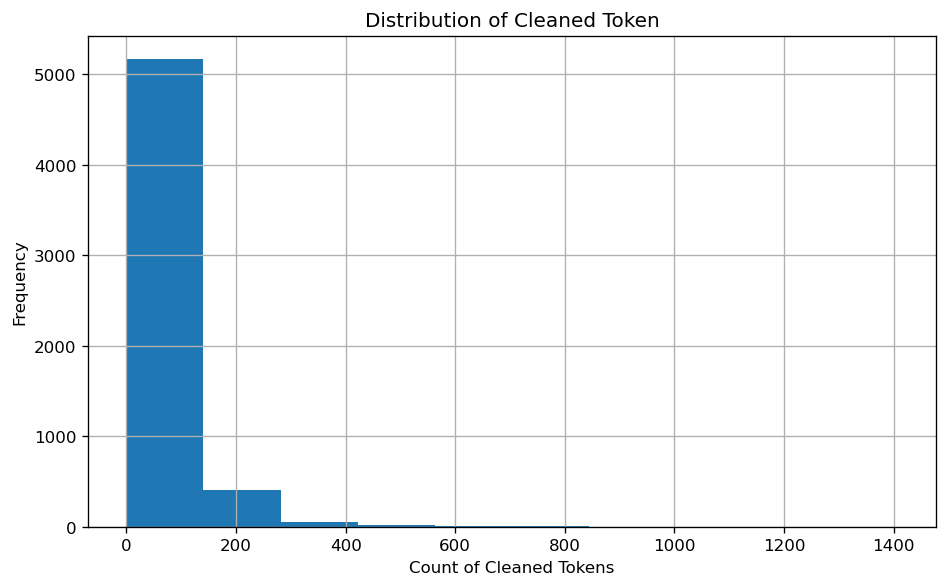

In [27]:
# TODO: Fill in the blanks to build a histogram of the n_tokens_clean column
ax = df['n_tokens_clean'].hist()
ax.set_xlabel('Count of Cleaned Tokens')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Cleaned Token')
plt.tight_layout()
plt.show()

In [29]:
# Most common cleaned unigrams
# optional TODO: update your CUSTOM_STOP list above if you see words on this list that you think should be removed with the stop words
all_toks = [t for row in df['tokens_clean'] for t in row]
cnt = Counter(all_toks)
top_cnt = pd.DataFrame(cnt.most_common(30), columns=['token','count'])
top_cnt.head(10)

,token,count
0,,38956
1,the,12412
2,to,8484
3,a,7061
4,and,6351
5,of,6141
6,it,5430
7,is,5371
8,i,5129
9,that,5076


In [31]:
# Most common bi-grams
def bigrams(lst):
    return list(zip(lst, lst[1:])) if len(lst) > 1 else []
all_bi = []
for row in df['tokens_clean']:
    all_bi.extend(bigrams(row))
bi_cnt = Counter(all_bi)
top_bi = pd.DataFrame([(f"{a} {b}", c) for (a,b), c in bi_cnt.most_common(30)], columns=['bigram','count'])
top_bi.head(10)

,bigram,count
0,,2920
1,i,2118
2,and,1917
3,but,1598
4,the,1373
5,it,1366
6,it s,1204
7,of the,1020
8,in the,949
9,do nt,688


In [ ]:
# Visualize with a wordcloud
wc = WordCloud(width=800, height=400, background_color='white')
text_blob = ' '.join(all_toks[:200000])  # cap for speed
img = wc.generate(text_blob).to_image()
display(img)

## Vectorization

For many applications and analyses, we will need to represent our text data in a numerical fashion, similar to producing a one-hot encoding for a categorical variable. *Term frequency* (TF) and *term frequency-inverse document frequency* (TF-IDF) vectors are two of the more common methods for vectorizing text data. 

A TF vector represents a document (in our case a single comment) as one vector with each position representing a word/token in our dataset. The value of each position for each document is the number of times that word shows up in that document (term frequency).

A TF-IDF vector is set up in the same way, but the value of each position is the number of times that word shows up in that document, divided by the number of documents that have the term.

These vectors are often combined into a single matrix for analysis, called a document-term matrix (since one axis will have the individual documents, and one axis will have the individual words).

**TODO**:
- Use scikit‑learn’s `CountVectorizer` to create a TF document‑term matrix. This function has cleaning steps built into it, so we will apply the function to our `text-norm` column. Choose the appropriate settings to convert the text to lowercase, remove stopwords, ignore words that are in more than 95% of documents, and ignore words that are in fewer than 5 documents.
- Use scikit‑learn’s `TfidfVectorizer` to create a TF-IDF document‑term matrix with the same cleaning settings as the TF matrix.

**Q**: What benefit do we get from using TF-IDF instead of the raw TF matrix?

**A**: TF-IDF focuses more on the words that are meaningful in a document and less focuses less on the highly repeated words(stop words). This helps identify more informative words and makes the data easier to analyze.

**Q**: What differences do you see between the TF and TF-IDF top terms shown below?

**A**: TF ranks words based on how often a word appear in each document. While TF-IDF ranks word based on how valuable the wrods are. In document 3679 ; TF top words are released,funny,telling ,point etc whereas 
 TF-IDF top words are bush, telling,released etc.

In [33]:
# TODO: Use the CountVectorizer function to create a TF document-term matrix with the settings described above.
cv = CountVectorizer(lowercase=True,stop_words='english',max_df=0.95, min_df=5)
X_tf = cv.fit_transform(df['text_norm'].fillna(''))
vocab = np.array(cv.get_feature_names_out())
X_tf.shape, len(vocab)

((5649, 4344), 4344)

In [35]:
# TODO: Use the TfidfVectorizer function to create a TF-IDF document-term matrix with the settings described above.
tfidf = TfidfVectorizer(lowercase=True,stop_words='english',max_df=0.95,min_df=5)
X_tfidf = tfidf.fit_transform(df['text_norm'].fillna(''))
tfidf_vocab = np.array(tfidf.get_feature_names_out())
X_tfidf.shape, len(tfidf_vocab)

((5649, 4344), 4344)

In [37]:
# Compare top tf anf tf-idf terms for a given doc
def top_terms(row_vector, vocab, k=10):
    row = row_vector.toarray().ravel()
    idx = row.argsort()[::-1][:k]
    return list(zip(vocab[idx], row[idx]))

# Show top terms for 3 random comments
for i in np.random.choice(X_tfidf.shape[0], size=3, replace=False):
    print(f"Doc {i} → top terms:")
    print("TF:")
    print(top_terms(X_tf[i], tfidf_vocab, k=10))
    print("TF-IDF:")
    print(top_terms(X_tfidf[i], tfidf_vocab, k=10))
    print('-'*60)

Doc 3679 → top terms:
TF:
[('released', 1), ('funny', 1), ('telling', 1), ('point', 1), ('bush', 1), ('level', 1), ('second', 1), ('government', 1), ('explanation', 0), ('explains', 0)]
TF-IDF:
[('bush', 0.45853205381042705), ('telling', 0.3902822557598265), ('released', 0.3826633965617294), ('funny', 0.38032584504732925), ('second', 0.3314872295171868), ('government', 0.31114558696457223), ('level', 0.29171055719459865), ('point', 0.2335780045059832), ('explicitly', 0.0), ('explicit', 0.0)]
------------------------------------------------------------
Doc 4001 → top terms:
TF:
[('yes', 17), ('shard', 5), ('multiple', 4), ('shards', 4), ('online', 4), ('groups', 2), ('ha', 2), ('workflows', 2), ('multi', 2), ('live', 2)]
TF-IDF:
[('yes', 0.6928598029700801), ('shard', 0.3490496417344449), ('shards', 0.28417191170894596), ('online', 0.22368417797514148), ('multiple', 0.1928302188096974), ('workflows', 0.14493285840428402), ('ha', 0.14208595585447298), ('groups', 0.12681859965137152), ('c

## Sentiment Analysis
Sentiment analysis is used to produce a score for the "sentiment" of each document in your corpus. It is mosty frequently useful in applications in which you would like to understand the sentiment of a large corpus (e.g. are product reviews generally good or bad) or for segmenting a dataset for further analysis (e.g. within positive reviews, what topics are most common).

Like tokenization and vectorization, sentiment analysis methods range greatly in their complexity. For this analysis we will be applying a static lexicon (VADER) to our text, which maps each word in the dataset to a sentiment score. These scores are then combined to produce a single score for each document--positive values indicate a positive sentiment, and negative values indicate a negative sentiment.

**Q**: What do you notice about our distribution of sentiment scores? How would you expect this to change if we were looking at a dataset of Amazon product reviews?

**A**: 

In [39]:
# Use the VADER sentiment lexicon to score our dataset
sia = SentimentIntensityAnalyzer()
scores = df['text_norm'].fillna('').apply(sia.polarity_scores)
df['sent_compound'] = scores.apply(lambda d: d['compound'])

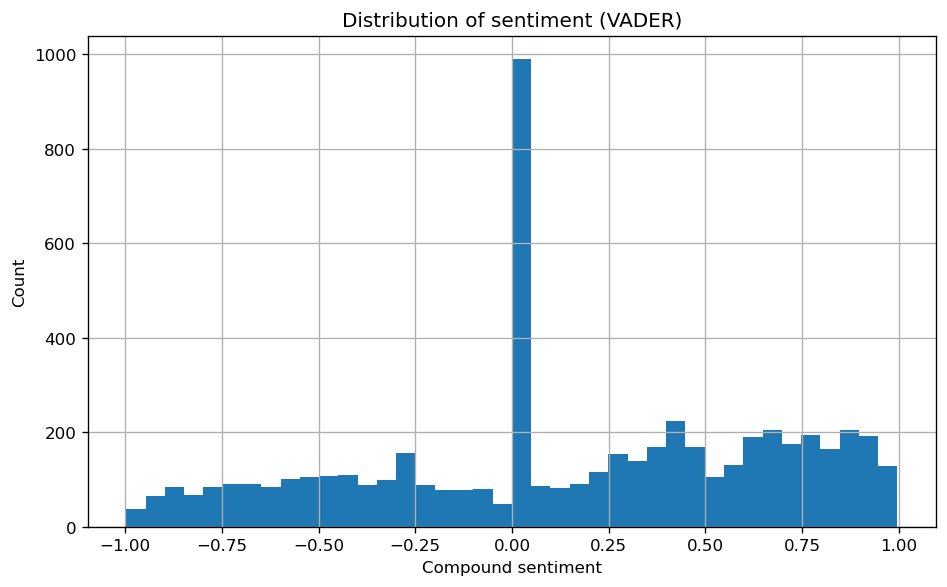

In [41]:
# Sentiment distribution
ax = df['sent_compound'].hist(bins=40)
ax.set_xlabel('Compound sentiment')
ax.set_ylabel('Count')
ax.set_title('Distribution of sentiment (VADER)')
plt.tight_layout()
plt.show()

## Save Engineered Features
We will save our modified dataset for future use.

In [45]:
features = df[['story_id','title','comment_id','user','text_norm','n_tokens_clean','sent_compound']].copy()
OUT_DIR = '/Users/sushmakafle/Documents/Master/ADS_509/Module1/ADS-509-module1/data/module2/' ## TODO: Update file path as needed
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, 'hn_comment_features.csv')
features.to_csv(OUT_CSV, index=False)
OUT_CSV

'/Users/sushmakafle/Documents/Master/ADS_509/Module1/ADS-509-module1/data/module2/hn_comment_features.csv'